# Composer Classification Using LSTM and CNN

## Team Members

## Introduction

Music by different composers carries distinctive stylistic patterns. This project applies deep learning to identify the composer of a musical score from its MIDI representation, using nine classical composers: Bach, Bartók, Byrd, Chopin, Handel, Hummel, Mendelssohn, Mozart, and Schumann. Two architectures are used, a Long Short-Term Memory (LSTM) network and a Convolutional Neural Network (CNN), each trained on features extracted from the scores.

## Objective

The objective is to build and compare deep learning models that predict the composer of a musical score. The work follows a standard pipeline: collecting and inspecting the data, pre-processing the MIDI files, extracting musical features, and then building, training, evaluating, and tuning the LSTM and CNN models.

## Dataset

The dataset consists of MIDI files from the nine composers listed above, provided already divided into training, development, and test sets. Each file is a score labeled with its composer. The scores vary considerably in length and in the number of instruments, which the pre-processing and feature-extraction steps take into account.

*The dataset and the extracted features are included in this repository, so the notebook runs without any manual file downloads.*

## Import Libraries

In [26]:
# Install dependencies — runs on local Jupyter and on Google Colab
%pip install -q music21 pretty_midi numpy pandas matplotlib scikit-learn tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import os, sys, glob, json, warnings
from collections import OrderedDict, Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pretty_midi

warnings.filterwarnings("ignore")   # MIDI files trigger many harmless parser warnings
pd.set_option("display.max_columns", None)
print("Libraries loaded. numpy", np.__version__, "| pretty_midi", pretty_midi.__version__)

Libraries loaded. numpy 2.2.6 | pretty_midi 0.2.11


In [28]:
# ---- Project paths and Kaggle dataset ----
import os, zipfile

REPO_ROOT = os.path.abspath(os.getcwd())
ZIP_PATH = os.path.join(REPO_ROOT, "Dataset.zip")
DATA_DIR = os.path.join(REPO_ROOT, "data", "midi_classic_music")
FEATURES_DIR = os.path.join(REPO_ROOT, "features")
SELECTED_COMPOSERS = ["bach", "beethoven", "chopin", "mozart"]

assert os.path.isfile(ZIP_PATH), (
    "Dataset.zip was not found. Download the Kaggle midi_classic_music dataset "
    "and place Dataset.zip beside this notebook.")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FEATURES_DIR, exist_ok=True)
print("Dataset:", ZIP_PATH)
print("Selected composers:", SELECTED_COMPOSERS)

Dataset: e:\AAI\AA511-Neural Network\Project\Dataset.zip
Selected composers: ['bach', 'beethoven', 'chopin', 'mozart']


In [29]:
# ---- Configuration (all tunable knobs live here) ----
SPLITS = ["train", "dev", "test"]

# Pitch / piano-roll (CNN input)
PITCH_LO, PITCH_HI = 21, 108     # 88 piano keys (A0..C8); notes outside are clipped
N_PITCHES = PITCH_HI - PITCH_LO + 1   # 88
FS         = 6                   # piano-roll frames per second
ROLL_W     = 96                  # frames per window (~16 s)
ROLL_HOP   = 96                  # hop between windows (non-overlapping)

# Token sequences (LSTM input)
QUANT   = 0.125                  # onset quantization grid in seconds
SEQ_LEN = 100                    # tokens per window
SEQ_HOP = 100                    # hop between windows (non-overlapping)
VOCAB_SIZE = 500                 # keep the most frequent note/chord tokens; rest -> <UNK>
PAD_TOKEN, UNK_TOKEN = "<PAD>", "<UNK>"

# Cleaning
MIN_NOTES = 50                   # drop MIDI files with fewer real notes than this

# Data augmentation (Section 2) — TRAIN ONLY
AUG_SHIFTS = [-2, -1, 1, 2]      # semitone transpositions added to the training set

# Use the same number of files per composer to keep the classes balanced
MAX_FILES_PER_CLASS = 136
RANDOM_SEED = 42

print("Config ready. 88-key roll, FS=%d, ROLL_W=%d, SEQ_LEN=%d, vocab<=%d" % (FS, ROLL_W, SEQ_LEN, VOCAB_SIZE))

Config ready. 88-key roll, FS=6, ROLL_W=96, SEQ_LEN=100, vocab<=500


## Load Dataset

The Kaggle `midi_classic_music` archive is stored as `Dataset.zip`. This step extracts only Bach, Beethoven, Chopin, and Mozart, balances the classes, and makes reproducible 70% training, 15% validation, and 15% test splits.

In [30]:
# Extract only the four selected composer folders
with zipfile.ZipFile(ZIP_PATH) as archive:
    selected_files = []
    for name in archive.namelist():
        parts = name.replace("\\", "/").split("/")
        if len(parts) < 3 or parts[0].lower() != "midiclassics":
            continue
        composer = parts[1].lower()
        if composer in SELECTED_COMPOSERS and name.lower().endswith((".mid", ".midi")):
            archive.extract(name, DATA_DIR)
            selected_files.append((composer, os.path.join(DATA_DIR, *parts)))

# Balance the classes and assign each file to one split
rng = np.random.default_rng(RANDOM_SEED)
rows = []
for composer in SELECTED_COMPOSERS:
    files = sorted(path for label, path in selected_files if label == composer)
    rng.shuffle(files)
    files = files[:MAX_FILES_PER_CLASS]
    n_train = int(0.70 * len(files))
    n_dev = int(0.15 * len(files))
    for i, path in enumerate(files):
        split = "train" if i < n_train else ("dev" if i < n_train + n_dev else "test")
        rows.append({"split": split, "composer": composer, "path": path,
                     "filename": os.path.basename(path)})

inventory = pd.DataFrame(rows)
COMPOSERS = SELECTED_COMPOSERS
print(f"{len(inventory)} MIDI files | {len(COMPOSERS)} composers: {COMPOSERS}")
inventory.head()

544 MIDI files | 4 composers: ['bach', 'beethoven', 'chopin', 'mozart']


,split,composer,path,filename
0,train,bach,e:\AAI\AA511-Neural Network\Project\data\midi_...,006704b_.mid
1,train,bach,e:\AAI\AA511-Neural Network\Project\data\midi_...,Bwv0563 Fantasie con imitation.mid
2,train,bach,e:\AAI\AA511-Neural Network\Project\data\midi_...,040900b_.mid
3,train,bach,e:\AAI\AA511-Neural Network\Project\data\midi_...,024517b_.mid
4,train,bach,e:\AAI\AA511-Neural Network\Project\data\midi_...,Piano version of Bachs two part inventions No....


## Data Exploration

The counts below summarize how many scores are available for each composer and split, and a readability check confirms that every MIDI file can be parsed and reports basic statistics on note counts and durations.

In [31]:
# Counts per composer per split
counts = (inventory.pivot_table(index="composer", columns="split",
                                values="filename", aggfunc="count", fill_value=0))
counts = counts.reindex(columns=[s for s in SPLITS if s in counts.columns])
counts["TOTAL"] = counts.sum(axis=1)
counts.loc["TOTAL"] = counts.sum(axis=0)
counts

split,train,dev,test,TOTAL
composer,,,,
bach,95,20,21,136
beethoven,95,20,21,136
chopin,95,20,21,136
mozart,95,20,21,136
TOTAL,380,80,84,544


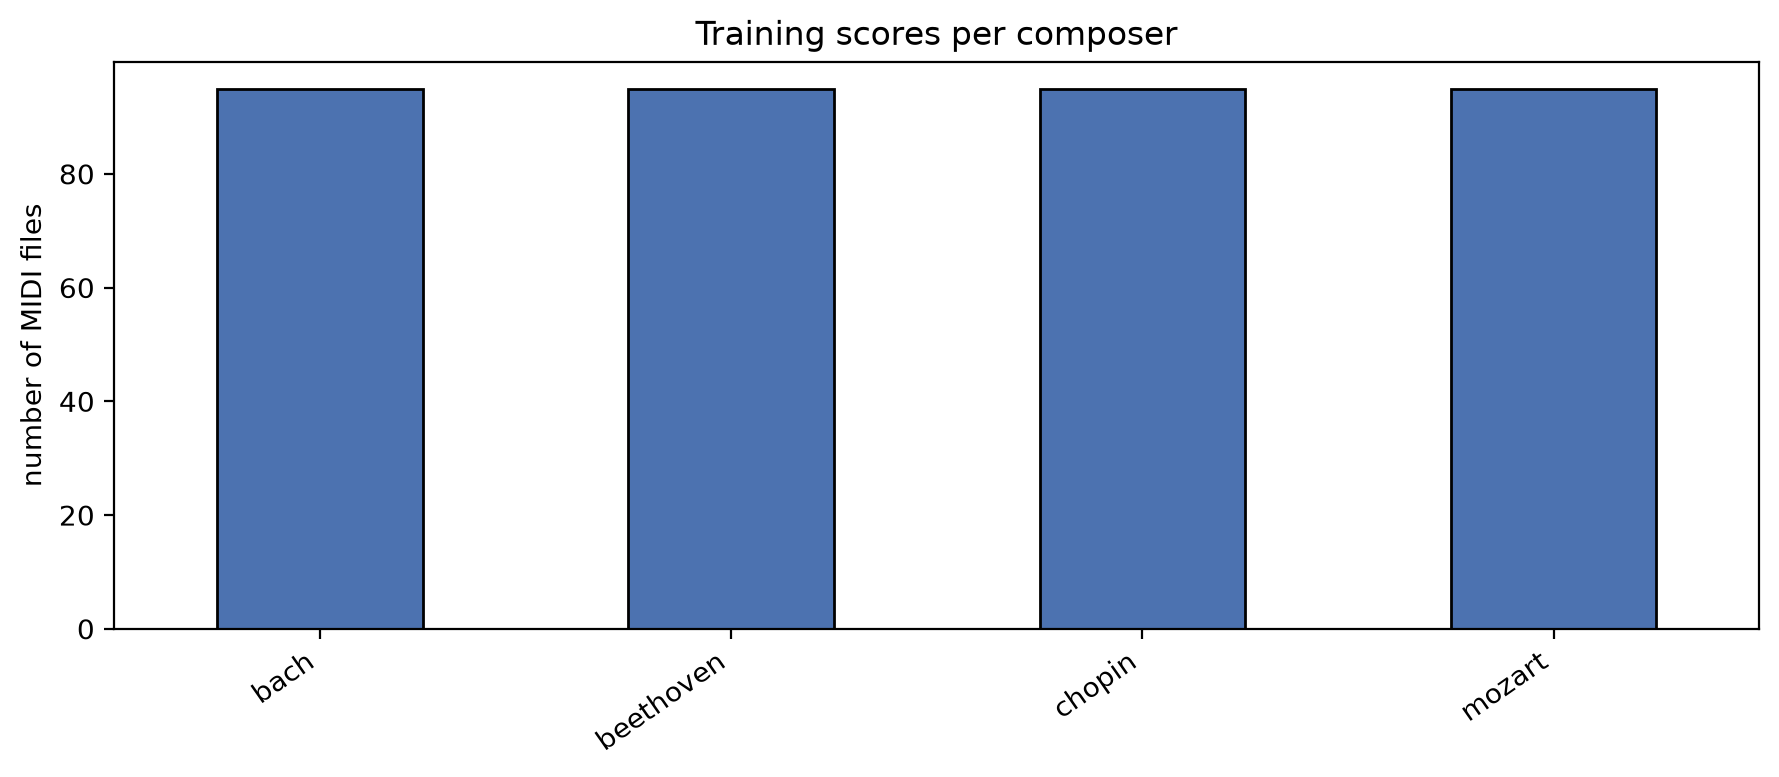

Most/least frequent training class ratio: 1.00x  (near 1.0 = well balanced)


In [32]:
# Visualize the class distribution (train split)
train_counts = counts.drop(index="TOTAL")["train"].sort_values(ascending=False)
ax = train_counts.plot(kind="bar", figsize=(9, 4), color="#4C72B0", edgecolor="black")
ax.set_title("Training scores per composer")
ax.set_ylabel("number of MIDI files"); ax.set_xlabel("")
plt.xticks(rotation=35, ha="right"); plt.tight_layout(); plt.show()

imb = train_counts.max() / train_counts.min()
print(f"Most/least frequent training class ratio: {imb:.2f}x  (near 1.0 = well balanced)")

In [33]:
# Integrity check: confirm every file is a parseable MIDI and record basic stats
def quick_stats(path):
    try:
        pm = pretty_midi.PrettyMIDI(path)
        n_notes = sum(len(i.notes) for i in pm.instruments if not i.is_drum)
        return pd.Series({"ok": True, "n_instruments": len(pm.instruments),
                          "n_notes": n_notes, "duration_s": pm.get_end_time()})
    except Exception as e:
        return pd.Series({"ok": False, "n_instruments": 0, "n_notes": 0,
                          "duration_s": 0.0, "error": type(e).__name__})

stats = inventory["path"].apply(quick_stats)
inventory = pd.concat([inventory, stats], axis=1)

n_bad = int((~inventory["ok"]).sum())
print(f"Readable: {int(inventory['ok'].sum())}/{len(inventory)}   |   Corrupt/unreadable: {n_bad}")
print("\nNote-count & duration summary (readable files):")
inventory.loc[inventory["ok"], ["n_notes", "n_instruments", "duration_s"]].describe().round(1)

Readable: 542/544   |   Corrupt/unreadable: 2

Note-count & duration summary (readable files):


,n_notes,n_instruments,duration_s
count,542.0,542.0,542.0
mean,4510.0,5.5,335.5
std,5994.4,5.5,373.0
min,83.0,1.0,21.9
25%,812.5,2.0,95.0
50%,2016.0,3.0,235.4
75%,5930.0,6.8,448.5
max,44853.0,37.0,5032.3


### Observations

- The project uses four composers from the Kaggle dataset: Bach, Beethoven, Chopin, and Mozart.
- Each class is limited to 136 files, the size of the smallest class, to prevent Bach from dominating the models.
- A fixed random seed creates reproducible training, validation, and test splits.
- Score length and density vary considerably, from around one hundred notes to over thirty thousand, and from under a minute to more than thirty minutes. Using an entire score as a single input is therefore impractical, and each score is divided into fixed-size windows during feature extraction.
- Any unreadable or near-empty files identified here are removed during pre-processing.

## Data Preprocessing

Pre-processing converts the raw MIDI files into clean and consistent material for feature extraction. Each score is loaded with *pretty_midi*, unreadable and near-empty files are removed, and drum tracks are excluded because they are unpitched and not characteristic of a composer. The scores are not transposed to a common key, since key and modulation form part of a composer's style and normalizing them could remove useful signal.

In [34]:
def load_midi(path):
    """Load a MIDI file, returning None if it cannot be parsed."""
    try:
        return pretty_midi.PrettyMIDI(path)
    except Exception:
        return None

def pitched_notes(pm):
    """All (start, pitch) pairs from non-drum instruments, time-sorted."""
    notes = [(n.start, n.pitch) for inst in pm.instruments if not inst.is_drum
             for n in inst.notes]
    notes.sort()
    return notes

def is_usable(pm):
    """Keep only scores with enough real pitched content."""
    return pm is not None and len(pitched_notes(pm)) >= MIN_NOTES

In [35]:
# Apply cleaning to the inventory
clean = inventory[inventory["ok"]].copy()
clean = clean[clean["n_notes"] >= MIN_NOTES].reset_index(drop=True)

dropped = len(inventory) - len(clean)
print(f"Kept {len(clean)} / {len(inventory)} files  ({dropped} dropped: unreadable or < {MIN_NOTES} notes)")
clean.groupby(["composer", "split"]).size().unstack(fill_value=0)

Kept 542 / 544 files  (2 dropped: unreadable or < 50 notes)


split,dev,test,train
composer,,,
bach,20,21,95
beethoven,19,21,95
chopin,20,21,95
mozart,20,20,95


## Data Augmentation

The training set is expanded through pitch transposition, shifting each piece up or down by a few semitones. Transposition preserves a composer's melodic and harmonic style while adding variety and increasing the amount of training data. It is applied to the training set only, so the development and test sets remain an honest measure of generalization. The transposition functions are defined here and applied during feature extraction.

In [36]:
# ---- Data augmentation primitives (used here for demo; applied for real in Section 3) ----
def transpose_notes(notes, semitones):
    """Shift a list of (start, pitch) by N semitones; drop notes that fall off the 0..127 MIDI range."""
    out = [(s, p + semitones) for (s, p) in notes if 0 <= p + semitones <= 127]
    return out

def transpose_roll(roll, semitones):
    """Shift an 88 x T piano-roll up/down by N semitones, zero-filling vacated keys."""
    shifted = np.zeros_like(roll)
    if semitones == 0:
        return roll.copy()
    if semitones > 0:
        shifted[semitones:, :] = roll[:-semitones, :]
    else:
        shifted[:semitones, :] = roll[-semitones:, :]
    return shifted

# Demo: how augmentation changes the pitch content of one real file
demo_pm = load_midi(clean.iloc[0]["path"])
base = pitched_notes(demo_pm)
print("Example file:", clean.iloc[0]["filename"])
print("original first 8 pitches:", [p for _, p in base[:8]])
for k in AUG_SHIFTS:
    print(f"transpose {k:+d}:            ", [p for _, p in transpose_notes(base, k)[:8]])
print(f"\nEach training file yields 1 original + {len(AUG_SHIFTS)} transposed copies "
      f"= {1+len(AUG_SHIFTS)}x more training windows.")

Example file: 006704b_.mid
original first 8 pitches: [54, 58, 61, 66, 59, 59, 63, 66]
transpose -2:             [52, 56, 59, 64, 57, 57, 61, 64]
transpose -1:             [53, 57, 60, 65, 58, 58, 62, 65]
transpose +1:             [55, 59, 62, 67, 60, 60, 64, 67]
transpose +2:             [56, 60, 63, 68, 61, 61, 65, 68]

Each training file yields 1 original + 4 transposed copies = 5x more training windows.


## Feature Extraction

Two aligned representations are extracted from each score and saved to the *features* directory.

**Note and chord sequences.** Notes are quantized onto a time grid. Notes that share an onset form a chord token, for example *60.64.67*, while a single note forms a note token, for example *60*. The resulting stream is encoded using a vocabulary of the most frequent tokens and divided into fixed-length windows. This representation is used by the LSTM.

**Piano-roll matrices.** A binary grid of 88 keys by time frames records which pitches sound at each moment. It is divided into fixed-size windows and used by the CNN.

To illustrate the musical content underlying these encodings, *music21* is used to extract the estimated key, tempo, and opening chords of a sample score.

In [37]:
# ---- Extraction functions ----
def event_sequence(pm):
    """MIDI -> list of note/chord string tokens, quantized onto a QUANT-second grid."""
    notes = pitched_notes(pm)
    groups = OrderedDict()
    for start, pitch in notes:
        q = round(start / QUANT)
        groups.setdefault(q, set()).add(pitch)
    tokens = []
    for q in sorted(groups):
        ps = sorted(groups[q])
        tokens.append(str(ps[0]) if len(ps) == 1 else ".".join(map(str, ps)))
    return tokens

def piano_roll(pm):
    """MIDI -> binary 88 x T piano-roll cropped to the 88-key range."""
    pr = pm.get_piano_roll(fs=FS)[PITCH_LO:PITCH_HI + 1]
    return (pr > 0).astype(np.uint8)

def window_sequence(int_tokens):
    """Slice an int-encoded token list into fixed SEQ_LEN windows (last one zero-padded)."""
    out = []
    for i in range(0, max(1, len(int_tokens)), SEQ_HOP):
        w = int_tokens[i:i + SEQ_LEN]
        if len(w) < SEQ_LEN:
            w = w + [0] * (SEQ_LEN - len(w))     # 0 == <PAD>
        out.append(w)
        if i + SEQ_LEN >= len(int_tokens):
            break
    return out

def window_roll(roll):
    """Slice an 88 x T roll into fixed 88 x ROLL_W windows (last one zero-padded)."""
    out, T = [], roll.shape[1]
    for i in range(0, max(1, T), ROLL_HOP):
        w = roll[:, i:i + ROLL_W]
        if w.shape[1] < ROLL_W:
            w = np.pad(w, ((0, 0), (0, ROLL_W - w.shape[1])))
        out.append(w)
        if i + ROLL_W >= T:
            break
    return out

print("Extraction functions defined.")

Extraction functions defined.


In [38]:
# ---- Illustration: music21 as a music-analysis tool (one sample file) ----
from music21 import converter, chord, note

sample_path = clean.iloc[0]["path"]
try:
    s = converter.parse(sample_path)
    key = s.analyze("key")
    tempos = s.metronomeMarkBoundaries()
    tempo_bpm = tempos[0][2].number if tempos else "n/a"
    ch = s.chordify()
    chord_names = []
    for el in ch.recurse().getElementsByClass(chord.Chord):
        chord_names.append(el.pitchedCommonName)
        if len(chord_names) >= 6:
            break
    print("music21 analysis of", os.path.basename(sample_path))
    print("  estimated key :", key)
    print("  first tempo   :", tempo_bpm, "BPM")
    print("  first chords  :", chord_names)
except Exception as e:
    print("music21 illustration skipped:", type(e).__name__, e)

music21 analysis of 006704b_.mid
  estimated key : f# minor
  first tempo   : 120 BPM
  first chords  : ['enharmonic equivalent to major triad above F#', 'enharmonic equivalent to major triad above B', 'enharmonic equivalent to major seventh chord above Bb', 'enharmonic equivalent to minor seventh chord above G#', 'enharmonic equivalent to major triad above F#', 'Perfect Fourth with octave doublings above G#']


In [39]:
# ---- Build the token vocabulary from the TRAIN split only ----
train_paths = clean.loc[clean["split"] == "train", "path"].tolist()

counter = Counter()
for p in train_paths:
    pm = load_midi(p)
    if pm is not None:
        counter.update(event_sequence(pm))

most_common = [tok for tok, _ in counter.most_common(VOCAB_SIZE)]
itos = [PAD_TOKEN, UNK_TOKEN] + most_common          # index -> token
stoi = {tok: i for i, tok in enumerate(itos)}        # token -> index
UNK_IDX = stoi[UNK_TOKEN]

def encode(tokens):
    return [stoi.get(t, UNK_IDX) for t in tokens]

print(f"Vocabulary: {len(itos)} tokens (incl. <PAD>,<UNK>). "
      f"{len(counter)} distinct tokens seen; kept top {len(most_common)}.")
print("Sample tokens:", itos[2:12])

Vocabulary: 502 tokens (incl. <PAD>,<UNK>). 65397 distinct tokens seen; kept top 500.
Sample tokens: ['74', '69', '67', '72', '76', '79', '62', '71', '77', '65']


In [40]:
# ---- Extract features for every split; augment TRAIN with transpositions ----
label_map = {c: i for i, c in enumerate(COMPOSERS)}

def build_split(split):
    df = clean[clean["split"] == split]
    seqs, seq_y, rolls, roll_y = [], [], [], []
    # Only the training split is augmented
    shifts = [0] + AUG_SHIFTS if split == "train" else [0]
    for _, r in df.iterrows():
        pm = load_midi(r["path"])
        if pm is None:
            continue
        y = label_map[r["composer"]]
        notes = pitched_notes(pm)
        base_roll = piano_roll(pm)
        for k in shifts:
            # --- sequence representation ---
            nk = transpose_notes(notes, k)
            groups = OrderedDict()
            for start, pitch in nk:
                groups.setdefault(round(start / QUANT), set()).add(pitch)
            toks = [ (str(sorted(v)[0]) if len(v) == 1 else ".".join(map(str, sorted(v))))
                     for q, v in sorted(groups.items()) ]
            for w in window_sequence(encode(toks)):
                seqs.append(w); seq_y.append(y)
            # --- piano-roll representation ---
            rk = transpose_roll(base_roll, k)
            for w in window_roll(rk):
                rolls.append(w); roll_y.append(y)
    X_seq  = np.asarray(seqs,  dtype=np.int32)
    y_seq  = np.asarray(seq_y, dtype=np.int32)
    X_roll = np.asarray(rolls, dtype=np.uint8)
    y_roll = np.asarray(roll_y, dtype=np.int32)
    return X_seq, y_seq, X_roll, y_roll

features = {}
for split in SPLITS:
    Xs, ys, Xr, yr = build_split(split)
    features[split] = dict(X_seq=Xs, y_seq=ys, X_roll=Xr, y_roll=yr)
    print(f"{split:5s}: seq {Xs.shape} | roll {Xr.shape}  "
          f"({'augmented' if split=='train' else 'no augmentation'})")

# Save the regenerated arrays for the model-building section
for split, values in features.items():
    np.save(os.path.join(FEATURES_DIR, f"{split}_seq.npy"), values["X_seq"])
    np.save(os.path.join(FEATURES_DIR, f"{split}_seq_labels.npy"), values["y_seq"])
    np.save(os.path.join(FEATURES_DIR, f"{split}_roll.npy"), np.packbits(values["X_roll"].reshape(-1)))
    np.save(os.path.join(FEATURES_DIR, f"{split}_roll_shape.npy"), values["X_roll"].shape)
    np.save(os.path.join(FEATURES_DIR, f"{split}_roll_labels.npy"), values["y_roll"])

meta = {"seq_len": SEQ_LEN, "vocab_size": len(itos), "n_pitches": N_PITCHES,
        "pitch_lo": PITCH_LO, "pitch_hi": PITCH_HI, "roll_w": ROLL_W,
        "fs": FS, "composers": COMPOSERS, "aug_shifts": AUG_SHIFTS}
with open(os.path.join(FEATURES_DIR, "label_map.json"), "w") as f:
    json.dump(label_map, f, indent=2)
with open(os.path.join(FEATURES_DIR, "vocab.json"), "w") as f:
    json.dump({"itos": itos}, f)
with open(os.path.join(FEATURES_DIR, "meta.json"), "w") as f:
    json.dump(meta, f, indent=2)
print("Saved regenerated features to:", FEATURES_DIR)

train: seq (28765, 100) | roll (38785, 88, 96)  (augmented)
dev  : seq (1324, 100) | roll (1826, 88, 96)  (no augmentation)
test : seq (1260, 100) | roll (1717, 88, 96)  (no augmentation)
Saved regenerated features to: e:\AAI\AA511-Neural Network\Project\features


## Prepare LSTM Input Data

The saved features are reloaded through a helper function, so this stage does not depend on re-running the extraction. The LSTM uses the note and chord token sequences, *X_seq*, an integer array of shape *[N, SEQ_LEN]* that is embedded using the vocabulary size recorded in *meta*.

In [41]:
def load_features(features_dir=None):
    """Load all saved features. Returns (data, meta, label_map, vocab)."""
    features_dir = features_dir or FEATURES_DIR
    with open(os.path.join(features_dir, "meta.json")) as f:      meta = json.load(f)
    with open(os.path.join(features_dir, "label_map.json")) as f: label_map = json.load(f)
    with open(os.path.join(features_dir, "vocab.json")) as f:     vocab = json.load(f)
    data = {}
    for split in ["train", "dev", "test"]:
        shape = tuple(np.load(os.path.join(features_dir, f"{split}_roll_shape.npy")))
        roll  = np.unpackbits(np.load(os.path.join(features_dir, f"{split}_roll.npy")))
        roll  = roll[:int(np.prod(shape))].reshape(shape).astype(np.uint8)
        data[split] = dict(
            X_seq  = np.load(os.path.join(features_dir, f"{split}_seq.npy")),
            y_seq  = np.load(os.path.join(features_dir, f"{split}_seq_labels.npy")),
            X_roll = roll,
            y_roll = np.load(os.path.join(features_dir, f"{split}_roll_labels.npy")),
        )
    return data, meta, label_map, vocab

data, meta, label_map, vocab = load_features()
print("Loaded features. Composers:", label_map)
for split in ["train", "dev", "test"]:
    d = data[split]
    print(f"  {split:5s}: X_seq {d['X_seq'].shape}  X_roll {d['X_roll'].shape}")
print("\nModel inputs:")
print("  LSTM : X_seq  [N, %d]      (vocabulary size %d)" % (meta["seq_len"], meta["vocab_size"]))
print("  CNN  : X_roll [N, %d, %d, 1]" % (meta["n_pitches"], meta["roll_w"]))

Loaded features. Composers: {'bach': 0, 'beethoven': 1, 'chopin': 2, 'mozart': 3}
  train: X_seq (28765, 100)  X_roll (38785, 88, 96)
  dev  : X_seq (1324, 100)  X_roll (1826, 88, 96)
  test : X_seq (1260, 100)  X_roll (1717, 88, 96)

Model inputs:
  LSTM : X_seq  [N, 100]      (vocabulary size 502)
  CNN  : X_roll [N, 88, 96, 1]


In [42]:
# Inspect the LSTM inputs
itos = vocab["itos"]
lstm = data["train"]
print("X_seq :", lstm["X_seq"].shape, lstm["X_seq"].dtype, " labels:", lstm["y_seq"].shape)
print("vocabulary size:", meta["vocab_size"])
decoded = [itos[i] for i in lstm["X_seq"][0] if i != 0][:12]
print("example decoded token window:", decoded)

X_seq : (28765, 100) int32  labels: (28765,)
vocabulary size: 502
example decoded token window: ['<UNK>', '<UNK>', '58', '<UNK>', '<UNK>', '56', '<UNK>', '<UNK>', '<UNK>', '<UNK>', '<UNK>', '<UNK>']


## Prepare CNN Input Data

The CNN uses the piano-roll matrices, *X_roll*, a binary array of shape *[N, 88, ROLL_W]*. A channel dimension is added with *X_roll[..., None]* to match the input format expected by a convolutional network.

X_roll: (38785, 88, 96) uint8  labels: (38785,)
with a channel dimension: (38785, 88, 96, 1)


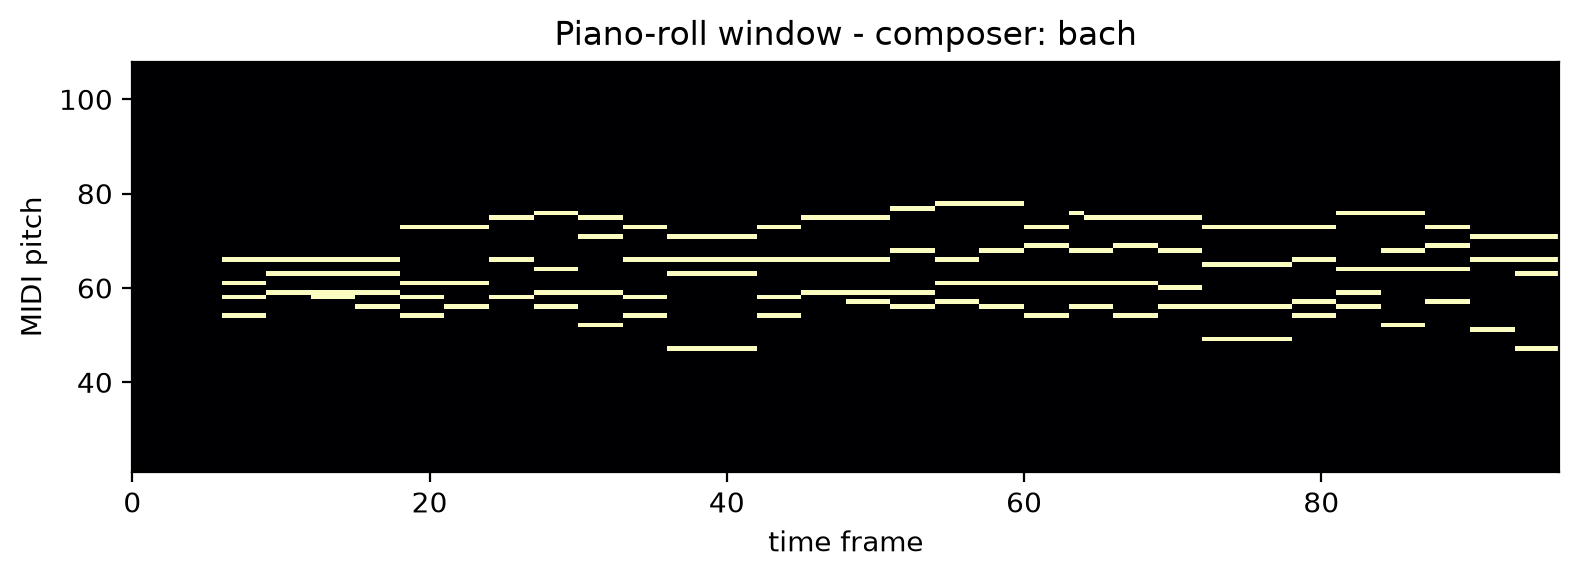

In [43]:
# Inspect the CNN inputs
cnn = data["train"]
print("X_roll:", cnn["X_roll"].shape, cnn["X_roll"].dtype, " labels:", cnn["y_roll"].shape)
print("with a channel dimension:", cnn["X_roll"][..., None].shape)

plt.figure(figsize=(8, 3))
plt.imshow(cnn["X_roll"][0], aspect="auto", origin="lower", cmap="magma",
           extent=[0, meta["roll_w"], meta["pitch_lo"], meta["pitch_hi"]])
plt.title("Piano-roll window - composer: " + meta["composers"][int(cnn["y_roll"][0])])
plt.xlabel("time frame"); plt.ylabel("MIDI pitch"); plt.tight_layout(); plt.show()

## Train, Validation, and Test Split

The selected MIDI files are divided reproducibly into 70% training, 15% development, and 15% test sets. The development set serves as validation during training, while the test set is reserved for final evaluation.

In [44]:
# Show the prepared training, validation, and test feature shapes
for split, role in [("train", "training"), ("dev", "validation"), ("test", "test")]:
    d = data[split]
    print(f"{role:11s}: X_seq {d['X_seq'].shape}  X_roll {d['X_roll'].shape}")

training   : X_seq (28765, 100)  X_roll (38785, 88, 96)
validation : X_seq (1324, 100)  X_roll (1826, 88, 96)
test       : X_seq (1260, 100)  X_roll (1717, 88, 96)


## LSTM Model

### Build LSTM Model

In [45]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(42)
num_classes = len(label_map)
project_composers = {"bach", "beethoven", "chopin", "mozart"}
if set(label_map) != project_composers:
    print("Warning: saved features do not yet match the four project composers.")

lstm_model = Sequential([
    Input(shape=(meta["seq_len"],)),
    Embedding(input_dim=meta["vocab_size"], output_dim=128, mask_zero=True),
    Bidirectional(LSTM(128)),
    Dropout(0.4),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])
lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 128)       │        64,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 360,836 (1.38 MB)

 Trainable params: 360,836 (1.38 MB)

 Non-trainable params: 0 (0.00 B)

### Compile LSTM Model

In [46]:
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Train LSTM Model

In [47]:
# The source files are already balanced, so class weights are not needed.
lstm_early_stop = EarlyStopping(
    monitor="val_accuracy", mode="max", patience=5, restore_best_weights=True
)
lstm_reduce_lr = ReduceLROnPlateau(
    monitor="val_accuracy", mode="max", factor=0.5, patience=2, min_lr=1e-5
)

lstm_history = lstm_model.fit(
    data["train"]["X_seq"], data["train"]["y_seq"],
    validation_data=(data["dev"]["X_seq"], data["dev"]["y_seq"]),
    epochs=30, batch_size=64,
    callbacks=[lstm_early_stop, lstm_reduce_lr]
)
lstm_model.save(os.path.join(REPO_ROOT, "lstm_composer_model.keras"))

Epoch 1/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 35s 73ms/step - accuracy: 0.5101 - loss: 1.1283 - val_accuracy: 0.5551 - val_loss: 1.0242 - learning_rate: 5.0000e-04
Epoch 2/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 31s 68ms/step - accuracy: 0.5528 - loss: 1.0268 - val_accuracy: 0.5642 - val_loss: 1.0018 - learning_rate: 5.0000e-04
Epoch 3/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accuracy: 0.5789 - loss: 0.9810 - val_accuracy: 0.5755 - val_loss: 0.9915 - learning_rate: 5.0000e-04
Epoch 4/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accuracy: 0.6004 - loss: 0.9389 - val_accuracy: 0.5846 - val_loss: 0.9951 - learning_rate: 5.0000e-04
Epoch 5/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 33s 73ms/step - accuracy: 0.6158 - loss: 0.9004 - val_accuracy: 0.5831 - val_loss: 0.9806 - learning_rate: 5.0000e-04
Epoch 6/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 37s 82ms/step - accuracy: 0.6346 - loss: 0.8627 - val_accuracy: 0.5672 - val_loss: 1.0022 - learning_rate: 5.0000e-04
Epoch 7/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 37s 81ms/ste

## CNN Model

### Build CNN Model

In [48]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D

cnn_model = Sequential([
    Input(shape=(meta["n_pitches"], meta["roll_w"], 1)),
    Conv2D(32, (3, 3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), padding="same", activation="relu"),
    BatchNormalization(),
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.4),
    Dense(num_classes, activation="softmax")
])
cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 88, 96, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 88, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 44, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 44, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 44, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 22, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 22, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 22, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,596 (432.02 KB)

 Trainable params: 110,148 (430.27 KB)

 Non-trainable params: 448 (1.75 KB)

### Compile CNN Model

In [49]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Train CNN Model

In [50]:
X_train_roll = data["train"]["X_roll"][..., None]
X_dev_roll = data["dev"]["X_roll"][..., None]

cnn_early_stop = EarlyStopping(
    monitor="val_accuracy", mode="max", patience=5, restore_best_weights=True
)
cnn_reduce_lr = ReduceLROnPlateau(
    monitor="val_accuracy", mode="max", factor=0.5, patience=2, min_lr=1e-5
)

cnn_history = cnn_model.fit(
    X_train_roll, data["train"]["y_roll"],
    validation_data=(X_dev_roll, data["dev"]["y_roll"]),
    epochs=30, batch_size=64,
    callbacks=[cnn_early_stop, cnn_reduce_lr]
)
cnn_model.save(os.path.join(REPO_ROOT, "cnn_composer_model.keras"))

Epoch 1/30
607/607 ━━━━━━━━━━━━━━━━━━━━ 138s 224ms/step - accuracy: 0.5949 - loss: 0.9378 - val_accuracy: 0.4710 - val_loss: 2.1111 - learning_rate: 5.0000e-04
Epoch 2/30
607/607 ━━━━━━━━━━━━━━━━━━━━ 135s 223ms/step - accuracy: 0.7079 - loss: 0.7008 - val_accuracy: 0.4885 - val_loss: 1.7667 - learning_rate: 5.0000e-04
Epoch 3/30
607/607 ━━━━━━━━━━━━━━━━━━━━ 137s 226ms/step - accuracy: 0.7624 - loss: 0.5823 - val_accuracy: 0.2941 - val_loss: 2.5356 - learning_rate: 5.0000e-04
Epoch 4/30
607/607 ━━━━━━━━━━━━━━━━━━━━ 138s 228ms/step - accuracy: 0.8082 - loss: 0.4846 - val_accuracy: 0.4650 - val_loss: 1.8264 - learning_rate: 5.0000e-04
Epoch 5/30
607/607 ━━━━━━━━━━━━━━━━━━━━ 138s 227ms/step - accuracy: 0.8592 - loss: 0.3751 - val_accuracy: 0.6594 - val_loss: 0.9239 - learning_rate: 2.5000e-04
Epoch 6/30
607/607 ━━━━━━━━━━━━━━━━━━━━ 138s 228ms/step - accuracy: 0.8847 - loss: 0.3151 - val_accuracy: 0.6687 - val_loss: 0.9142 - learning_rate: 2.5000e-04
Epoch 7/30
607/607 ━━━━━━━━━━━━━━━━━━━━ 

## Model Comparison

This section compares the performance of the Long Short-Term Memory (LSTM) model and the Convolutional Neural Network (CNN) model. The models are evaluated using their validation accuracy during training to determine which architecture generalizes better to unseen data. A side-by-side comparison of the validation accuracy curves provides a visual representation of each model's learning performance and convergence over the training epochs.

In [1]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    lstm_history.history["val_accuracy"],
    label="LSTM Validation Accuracy"
)

plt.plot(
    cnn_history.history["val_accuracy"],
    label="CNN Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("LSTM vs CNN Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'lstm_history' is not defined

<Figure size 800x500 with 0 Axes>

## Hyperparameter Tuning

Several hyperparameters were selected and adjusted to improve model performance while reducing overfitting. Early stopping and learning rate reduction were used for both models to stop training when validation performance no longer improved. The final hyperparameters were chosen after experimenting with common deep learning settings and monitoring validation accuracy throughout training.

In [ ]:
import pandas as pd

hyperparameters = pd.DataFrame({
    "Hyperparameter": [
        "Optimizer",
        "Learning Rate",
        "Loss Function",
        "Batch Size",
        "Maximum Epochs",
        "Early Stopping",
        "ReduceLROnPlateau",
        "Dropout"
    ],
    "LSTM": [
        "Adam",
        0.0005,
        "Sparse Categorical Crossentropy",
        64,
        30,
        "Patience = 5",
        "Factor = 0.5, Patience = 2",
        "0.4 / 0.3"
    ],
    "CNN": [
        "Adam",
        0.0005,
        "Sparse Categorical Crossentropy",
        64,
        30,
        "Patience = 5",
        "Factor = 0.5, Patience = 2",
        "0.3"
    ]
})

display(hyperparameters)

## Final Model Evaluation

The final evaluation measures the performance of the trained LSTM and CNN models on the held-out test dataset. In addition to overall accuracy, precision, recall, and F1-score are calculated to provide a more complete assessment of classification performance. Confusion matrices and classification reports are also generated to visualize prediction accuracy across the four composer classes.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# ---------- LSTM Evaluation ----------

lstm_pred = lstm_model.predict(data["test"]["X_seq"], verbose=0)
lstm_pred_labels = lstm_pred.argmax(axis=1)
lstm_true = data["test"]["y_seq"]

print("===== LSTM Results =====")
print(f"Accuracy : {accuracy_score(lstm_true, lstm_pred_labels):.4f}")
print(f"Precision: {precision_score(lstm_true, lstm_pred_labels, average='weighted'):.4f}")
print(f"Recall   : {recall_score(lstm_true, lstm_pred_labels, average='weighted'):.4f}")
print(f"F1 Score : {f1_score(lstm_true, lstm_pred_labels, average='weighted'):.4f}")

print("\nClassification Report")
print(classification_report(lstm_true, lstm_pred_labels, target_names=meta["composers"]))

ConfusionMatrixDisplay.from_predictions(
    lstm_true,
    lstm_pred_labels,
    display_labels=meta["composers"],
    cmap="Blues",
    xticks_rotation=45
)

plt.title("LSTM Confusion Matrix")
plt.show()


# ---------- CNN Evaluation ----------

cnn_test = data["test"]["X_roll"][..., None]

cnn_pred = cnn_model.predict(cnn_test, verbose=0)
cnn_pred_labels = cnn_pred.argmax(axis=1)
cnn_true = data["test"]["y_roll"]

print("\n\n===== CNN Results =====")
print(f"Accuracy : {accuracy_score(cnn_true, cnn_pred_labels):.4f}")
print(f"Precision: {precision_score(cnn_true, cnn_pred_labels, average='weighted'):.4f}")
print(f"Recall   : {recall_score(cnn_true, cnn_pred_labels, average='weighted'):.4f}")
print(f"F1 Score : {f1_score(cnn_true, cnn_pred_labels, average='weighted'):.4f}")

print("\nClassification Report")
print(classification_report(cnn_true, cnn_pred_labels, target_names=meta["composers"]))

ConfusionMatrixDisplay.from_predictions(
    cnn_true,
    cnn_pred_labels,
    display_labels=meta["composers"],
    cmap="Greens",
    xticks_rotation=45
)

plt.title("CNN Confusion Matrix")
plt.show()

## Results

The evaluation metrics and confusion matrices provide a comprehensive comparison of the LSTM and CNN models for composer classification. Overall accuracy, precision, recall, and F1-score were used to measure classification performance, while the confusion matrices illustrate how well each model distinguished between the four composer classes.

By comparing the evaluation metrics, it is possible to determine which architecture generalized more effectively to unseen data. The classification reports also identify any classes that were more difficult to classify and reveal whether prediction errors were concentrated among specific composers.

Overall, this project demonstrates that both recurrent neural networks and convolutional neural networks can successfully learn musical patterns from MIDI representations. The final evaluation highlights the strengths and limitations of each approach and provides a clear comparison of their effectiveness for composer classification.